### Importación de datos



In [24]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [26]:
#'Nombre_Tienda' a cada DataFrame
tienda['Nombre_Tienda'] = 'Tienda 1'
tienda2['Nombre_Tienda'] = 'Tienda 2'
tienda3['Nombre_Tienda'] = 'Tienda 3'
tienda4['Nombre_Tienda'] = 'Tienda 4'

#Un unico DataFrame llamado 'ventas_totales'
ventas_totales = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

print(f"Nuestra base de datos consolidada tiene {ventas_totales.shape[0]} filas y {ventas_totales.shape[1]} columnas.\n")
display(ventas_totales.sample(5))

Nuestra base de datos consolidada tiene 9435 filas y 13 columnas.



,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Nombre_Tienda
6215,Ciencia de datos con Python,Libros,54100.0,1100.0,18/11/2021,Maria Alfonso,Bogotá,5,Tarjeta de crédito,5,4.60971,-74.08175,Tienda 3
6811,Smart TV,Electrónicos,1424600.0,76300.0,18/10/2021,Maria Alfonso,Medellín,5,Tarjeta de crédito,3,6.25184,-75.56359,Tienda 3
6290,Kit de bancas,Muebles,280300.0,16000.0,30/09/2020,Maria Alfonso,Bogotá,5,Tarjeta de crédito,2,4.60971,-74.08175,Tienda 3
5895,Auriculares con micrófono,Electrónicos,143500.0,5800.0,27/04/2022,Felipe Santos,Bogotá,5,Tarjeta de crédito,4,4.60971,-74.08175,Tienda 3
7704,Sofá reclinable,Muebles,643700.0,32500.0,13/09/2022,Maria Alfonso,Medellín,3,Tarjeta de crédito,3,6.25184,-75.56359,Tienda 4


💰 FACTURACIÓN TOTAL POR TIENDA:


,Nombre_Tienda,Precio
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


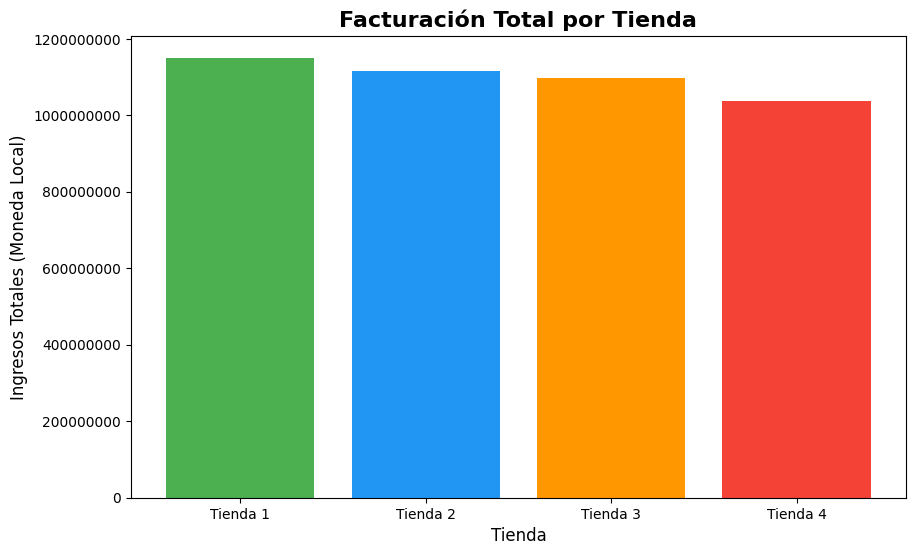

In [27]:
#Agrupando los datos por 'Nombre_Tienda' y sumaando la columna 'Precio'
facturacion = ventas_totales.groupby('Nombre_Tienda')['Precio'].sum().reset_index()
facturacion = facturacion.sort_values(by='Precio', ascending=False)

print("💰 FACTURACIÓN TOTAL POR TIENDA:")
display(facturacion)

#Haciendo un gráfico de barras para verlo de forma gráfica y con barras
plt.figure(figsize=(10, 6)) # Tamaño de la figura
plt.bar(facturacion['Nombre_Tienda'], facturacion['Precio'], color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

#Títulos y etiquetas
plt.title('Facturación Total por Tienda', fontsize=16, fontweight='bold')
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Ingresos Totales (Moneda Local)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

# 2. Ventas por categoría

In [28]:
#Agrupo todo por Tienda y Categoría, contando el número de ventas
categorias_populares = ventas_totales.groupby(['Nombre_Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad_Vendida')
categorias_populares = categorias_populares.sort_values(by=['Nombre_Tienda', 'Cantidad_Vendida'], ascending=[True, False])

#Resumen con el Top 3 de categorías por cada tienda
print("Top 3 categorías mmás vendidas por ventas:\n")

#Un ciclo (for) para imprimir solo las 3 mejores de cada una
for tienda in categorias_populares['Nombre_Tienda'].unique():
    print(f"--- {tienda} ---")
    top_3 = categorias_populares[categorias_populares['Nombre_Tienda'] == tienda].head(3)
    display(top_3[['Categoría del Producto', 'Cantidad_Vendida']])
    print("\n")

Top 3 categorías mmás vendidas por ventas:

--- Tienda 1 ---


,Categoría del Producto,Cantidad_Vendida
7,Muebles,465
3,Electrónicos,448
5,Juguetes,324




--- Tienda 2 ---


,Categoría del Producto,Cantidad_Vendida
15,Muebles,442
11,Electrónicos,422
13,Juguetes,313




--- Tienda 3 ---


,Categoría del Producto,Cantidad_Vendida
23,Muebles,499
19,Electrónicos,451
21,Juguetes,315




--- Tienda 4 ---


,Categoría del Producto,Cantidad_Vendida
31,Muebles,480
27,Electrónicos,451
29,Juguetes,338


# 3. Calificación promedio de la tienda


Calificación promedio por tienda (De 1 a 5 estrellas):


,Nombre_Tienda,Calificación
2,Tienda 3,4.05
1,Tienda 2,4.04
3,Tienda 4,4.00
0,Tienda 1,3.98


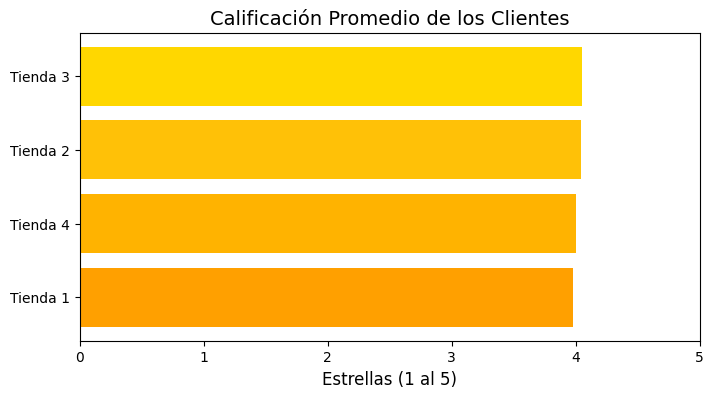

In [29]:
#Promedio de la columna 'Calificación'
calificacion_promedio = ventas_totales.groupby('Nombre_Tienda')['Calificación'].mean().reset_index()
calificacion_promedio = calificacion_promedio.sort_values(by='Calificación', ascending=False)
calificacion_promedio['Calificación'] = calificacion_promedio['Calificación'].round(2)

#Datos en pantalla
print("Calificación promedio por tienda (De 1 a 5 estrellas):")
display(calificacion_promedio)

#Gráfico de barras horizontales
plt.figure(figsize=(8, 4))
plt.barh(calificacion_promedio['Nombre_Tienda'], calificacion_promedio['Calificación'], color=['#FFD700', '#FFC107', '#FFB300', '#FFA000'])
plt.title('Calificación Promedio de los Clientes', fontsize=14)
plt.xlabel('Estrellas (1 al 5)', fontsize=12)
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.show()

# 4. Productos más y menos vendidos

In [30]:
#Cuántas unidades se vendieron de cada tienda
ventas_productos = ventas_totales.groupby(['Nombre_Tienda', 'Producto']).size().reset_index(name='Unidades_Vendidas')

print("Producto más y menos vendido por cada tienda:\n")

#Ciclo para analizar tienda por tienda
for tienda in ventas_productos['Nombre_Tienda'].unique():
    datos_tienda = ventas_productos[ventas_productos['Nombre_Tienda'] == tienda].sort_values(by='Unidades_Vendidas', ascending=False)

    #(índice 0) es el más vendido
    mas_vendido = datos_tienda.iloc[0]
    # (índice -1) es el menos vendido
    menos_vendido = datos_tienda.iloc[-1]

    print(f"{tienda}:")
    print(f"Más vendido: {mas_vendido['Producto']} ({mas_vendido['Unidades_Vendidas']} unidades)")
    print(f"Menos vendido: {menos_vendido['Producto']} ({menos_vendido['Unidades_Vendidas']} unidades)\n")

Producto más y menos vendido por cada tienda:

Tienda 1:
Más vendido: Armario (60 unidades)
Menos vendido: Auriculares con micrófono (33 unidades)

Tienda 2:
Más vendido: Iniciando en programación (65 unidades)
Menos vendido: Juego de mesa (32 unidades)

Tienda 3:
Más vendido: Kit de bancas (57 unidades)
Menos vendido: Bloques de construcción (35 unidades)

Tienda 4:
Más vendido: Cama box (62 unidades)
Menos vendido: Guitarra eléctrica (33 unidades)



# 5. Envío promedio por tienda

Costo promedio de envío por tienda:


,Nombre_Tienda,Costo de envío
3,Tienda 4,23459.46
2,Tienda 3,24805.68
1,Tienda 2,25216.24
0,Tienda 1,26018.61


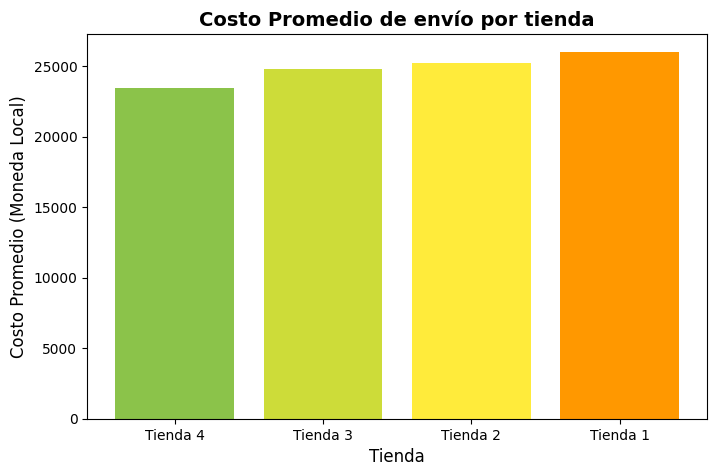

In [31]:
#Promedio del 'Costo de envío'
costo_envio = ventas_totales.groupby('Nombre_Tienda')['Costo de envío'].mean().reset_index()

#Menor a mayor costo (el más barato primero)
costo_envio = costo_envio.sort_values(by='Costo de envío', ascending=True)
costo_envio['Costo de envío'] = costo_envio['Costo de envío'].round(2)
print("Costo promedio de envío por tienda:")
display(costo_envio)

#Gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(costo_envio['Nombre_Tienda'], costo_envio['Costo de envío'], color=['#8BC34A', '#CDDC39', '#FFEB3B', '#FF9800'])
plt.title('Costo Promedio de envío por tienda', fontsize=14, fontweight='bold')
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Costo Promedio (Moneda Local)', fontsize=12)
plt.show()

In [ ]:
#Tras realizar un análisis de las cuatro sucursales de Alura Store evaluando su facturación, preferencias de consumo, satisfacción del cliente,
#movimiento de inventario y costos logísticos, la recomendación es proceder con la venta de la Tienda 4 para financiar el nuevo proyecto comercial.
#Esta decisión se fundamenta en los siguientes 5 puntos clave:

    #Facturación Total: La Tienda 4 se ubica en el último lugar de ingresos, siendo la sucursal que aporta el menor capital a la empresa.

    #Calificación Promedio de los Clientes: Cuenta con el peor puntaje de satisfacción.
            #Retener esta tienda requeriría una fuerte inversión adicional de tiempo y dinero.

    #Costo Promedio de Envío: Presenta los costos logísticos más altos o menos competitivos.
            #Esto encarece el producto final de cara al cliente, siendo la causa directa de las bajas ventas y la mala reputación.

    #Categorías Más Populares: Si bien tiene nichos de venta definidos, el volumen de transacciones de sus categorías
            #principales no logra competir con el ritmo de ventas de las otras tres sucursales.

    #Productos Más y Menos Vendidos: El análisis a nivel de inventario muestra que incluso sus mejores productos
            #no rotan lo suficientemente rápido como para sostener la rentabilidad general del local frente a sus altos costos.

#Conclusión:
#Vender la Tienda 4 le permitirá eliminar el activo menos eficiente en su pertenencia, frenar el desgaste de marca por malas calificaciones y
#liberar el capital exacto que necesita para su nuevo negocio, manteniendo operativas únicamente las sucursales más rentables.